In [1]:
import pandas as pd

In [3]:
df=pd.read_csv('/content/students_scores_final exam_dataset.csv')

In [4]:
df

,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
0,10001,24,73,69,70,6.6,1
1,10002,17,72,62,70,5.2,1
2,10003,24,54,79,74,6.9,1
3,10004,22,95,58,65,8.9,1
4,10005,20,79,53,76,5.0,1
...,...,...,...,...,...,...,...
4995,14996,22,59,54,62,5.4,1
4996,14997,25,66,67,78,7.1,1
4997,14998,20,100,93,100,12.0,1
4998,14999,25,73,53,59,7.3,1


In [5]:
df.head()

,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
0,10001,24,73,69,70,6.6,1
1,10002,17,72,62,70,5.2,1
2,10003,24,54,79,74,6.9,1
3,10004,22,95,58,65,8.9,1
4,10005,20,79,53,76,5.0,1


In [13]:
df.shape

(5000, 7)

**# 1.measure of centreal tendency & dispersion**

#1.1 calculating mean,median,mode of maths score

In [8]:
import numpy as np
mean=np.mean(df['Science_Score'])
median=np.median(df['Science_Score'])
mode=df['Science_Score'].mode()[0]
print('mean is',round(mean))
print('median is',median)
print('mode is',mode)



mean is 65
median is 65.0
mode is 66


## 1.2 find range,variance and standard deviation of science score

In [9]:

s_dev=np.std(df['Science_Score'])
variance=np.var(df['Science_Score'])
range_=np.max(df['Science_Score'])-np.min(df['Science_Score'])
print('standard deviation is',round(s_dev,2))
print('variance is',round(variance,2))
print('range is',range)


standard deviation is 13.1
variance is 171.72
range is <class 'range'>


**2.Probability Basics**


# 2.1 Probability of Students Passing

In [14]:
total_students = len(df)
passed_students = (df["Pass_Fail"] == 1).sum()

probability_pass = passed_students / total_students

print("Total Students :", total_students)
print("Passed Students:", passed_students)
print(f"Probability of Passing: {round(probability_pass * 100, 2)}%")

Total Students : 5000
Passed Students: 4971
Probability of Passing: 99.42%


# 2.2 Contingency Table — Pass_Fail vs Hours_Studied > 5

In [18]:
df["Studied_More_Than_5"] = df["Hours_Studied"] > 5

contingency_table = pd.crosstab(
    df["Pass_Fail"],
    df["Studied_More_Than_5"]
)

print("Contingency Table:")
display(contingency_table)

Contingency Table:


Studied_More_Than_5,False,True
Pass_Fail,,
0,28,1
1,2043,2928


# 2.3 conditional probability
# p(pass/hours_studied > 5)

In [21]:
more_than_5 = df[df["Hours_Studied"] > 5]

conditional_probability = (
    (more_than_5["Pass_Fail"] == 1).sum()
    / len(more_than_5)
)

print(f"P(Pass | Hours_Studied > 5) = {round(conditional_probability * 100, 2)}%")

P(Pass | Hours_Studied > 5) = 99.97%


**3. Distribution & Visualization**

# 3.1 Histogram + Normal Curve — Math Score

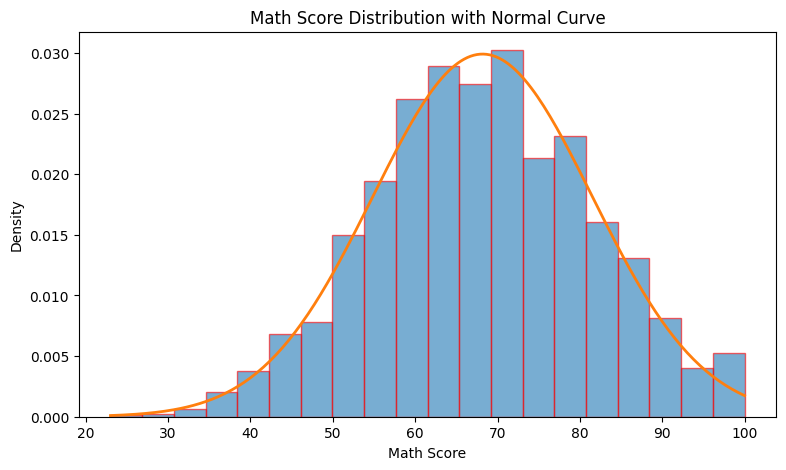

In [24]:
import matplotlib.pyplot as plt
import scipy.stats as stats

math = df["Math_Score"]

mean = math.mean()
std = math.std()

plt.figure(figsize=(9,5))

plt.hist(
    math,
    bins=20,
    density=True,
    alpha=0.6,
    edgecolor="red"
)

x = np.linspace(math.min(), math.max(), 200)
normal_curve = stats.norm.pdf(x, mean, std)

plt.plot(x, normal_curve, linewidth=2)

plt.xlabel("Math Score")
plt.ylabel("Density")
plt.title("Math Score Distribution with Normal Curve")
plt.show()

# 3.2 Skewness & Kurtosis — Science Score

In [32]:
science_skewness = df["Science_Score"].skew()
science_kurtosis = df["Science_Score"].kurt()

print(f"Science Score Skewness : {round(science_skewness * 100, 2)}%")
print(f"Science Score Kurtosis : {round(science_kurtosis * 100, 2)}%")
if science_skewness > 0:
    print("Distribution: Positively skewed")
elif science_skewness < 0:
    print("Distribution: Negatively skewed")
else:
    print("Distribution: Approximately symmetric")
# Corrected indentation here
if science_kurtosis > 0:
    print("Distribution: Positively kurtosis")
elif science_kurtosis < 0:
    print("Distribution: Negatively kurtosis")
else:
    print("Distribution: Approximately symmetric")

Science Score Skewness : 1.99%
Science Score Kurtosis : -5.91%
Distribution: Positively skewed
Distribution: Negatively kurtosis


# 3.3 Q-Q Plot — English Score

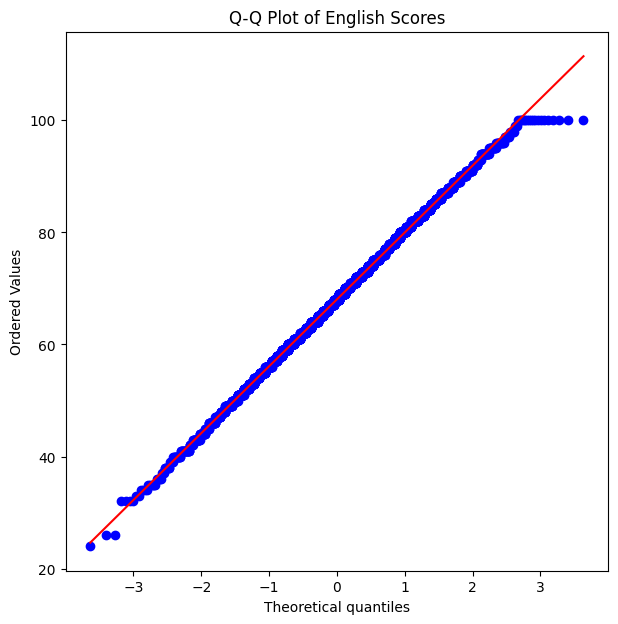

In [33]:
plt.figure(figsize=(7,7))

stats.probplot(
    df["English_Score"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of English Scores")
plt.show()

**4 — Linear Algebra Mini Task**

# first 5 students ke math and science scores ko vectors  me represent.

In [40]:
math_vector = df["Math_Score"].head(5).to_numpy()
science_vector = df["Science_Score"].head(5).to_numpy()

print("Math Vector:")
print(math_vector)

print("\nScience Vector:")
print(science_vector)

Math Vector:
[73 72 54 95 79]

Science Vector:
[69 62 79 58 53]


# dot product of 2 vectors

In [36]:
dot_product = np.dot(math_vector, science_vector)

print("Dot Product:", dot_product)

Dot Product: 51471


# norm 1 and norm 2 of math  score vector

In [39]:
norm_1 = np.linalg.norm(math_vector, ord=1)
norm_2 = np.linalg.norm(math_vector, ord=2)

print(" Math Vector:", round(norm_1, 2))
print(" Math Vector:", round(norm_2, 2))

 Math Vector: 784.0
 Math Vector: 251.56


In [41]:
# First 5 students ke vectors
math_vector = df["Math_Score"].head(5).to_numpy()
science_vector = df["Science_Score"].head(5).to_numpy()

# Dot product
dot_product = np.dot(math_vector, science_vector)

# L2 norms
norm_math = np.linalg.norm(math_vector)
norm_science = np.linalg.norm(science_vector)

# Angle formula
cos_theta = dot_product / (norm_math * norm_science)
angle = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print("Math Vector:", math_vector)
print("Science Vector:", science_vector)
print("Dot Product:", dot_product)
print("Math Vector L2 Norm:", round(norm_math, 2))
print("Science Vector L2 Norm:", round(norm_science, 2))
print("Angle between the vectors:", round(angle, 2), "degrees")

Math Vector: [73 72 54 95 79]
Science Vector: [69 62 79 58 53]
Dot Product: 23464
Math Vector L2 Norm: 169.4
Science Vector L2 Norm: 144.98
Angle between the vectors: 17.17 degrees
